# **Data Communication and Ethics Final Project**

Student Name - Khant Razar Kyaw

Course - DATA 201:Data Communications and Ethics

Assignment - Final Project: Personal Story Dashboard

### **1. Data Loading and Preparation**

In [1]:
# Import required libraries

import pandas as pd     # data handling, tables, and dataframes
import numpy as np      # for mathematical operations
import matplotlib.pyplot as plt  # Basic graphs
import seaborn as sns   # Advanced visualization

In [2]:
# Data loading

df = pd.read_csv('Khant_Journey.csv')  # load csv file into pd dataframe
df.head()

,Semester,Academic_Year,Attempted_Credits,Semester_GPA,Tech_Data_Credits,Hum_Soc_Credits,Active_Clubs,Primary_Leadership,Est_Club_Hours_Weekly,Leadership_Impact_Score
0,Fall 2023,Year 1,18,3.87,3,15,"Debate, Datalliance, Environmental",CEDI,10,3
1,Spring 2024,Year 1,18,3.66,6,12,"Debate, Datalliance, Environmental",NaN,10,4
2,Fall 2024,Year 2,16,3.44,3,13,"Debate, Datalliance",CIIF,8,4
3,Spring 2025,Year 2,14,3.8,2,12,"Debate, Datalliance",NaN,8,4
4,Fall 2025,Year 3,20,3.53,20,0,Debate,NaN,4,5


In [3]:
# add a new column culumulative credits
df['Cumulative_Credits'] = df['Attempted_Credits'].cumsum()  # Calculate the running total of credits accrued over time
df.head(2)

,Semester,Academic_Year,Attempted_Credits,Semester_GPA,Tech_Data_Credits,Hum_Soc_Credits,Active_Clubs,Primary_Leadership,Est_Club_Hours_Weekly,Leadership_Impact_Score,Cumulative_Credits
0,Fall 2023,Year 1,18,3.87,3,15,"Debate, Datalliance, Environmental",CEDI,10,3,18
1,Spring 2024,Year 1,18,3.66,6,12,"Debate, Datalliance, Environmental",NaN,10,4,36


### **2. Exploratory Data Analysis**

In [4]:
df.info()   # Check column names, data types, and counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Semester                 6 non-null      object
 1   Academic_Year            6 non-null      object
 2   Attempted_Credits        6 non-null      int64 
 3   Semester_GPA             6 non-null      object
 4   Tech_Data_Credits        6 non-null      int64 
 5   Hum_Soc_Credits          6 non-null      int64 
 6   Active_Clubs             6 non-null      object
 7   Primary_Leadership       3 non-null      object
 8   Est_Club_Hours_Weekly    6 non-null      int64 
 9   Leadership_Impact_Score  6 non-null      int64 
 10  Cumulative_Credits       6 non-null      int64 
dtypes: int64(6), object(5)
memory usage: 656.0+ bytes


In [5]:
df.isnull().sum()  # check for missing values

Semester                   0
Academic_Year              0
Attempted_Credits          0
Semester_GPA               0
Tech_Data_Credits          0
Hum_Soc_Credits            0
Active_Clubs               0
Primary_Leadership         3
Est_Club_Hours_Weekly      0
Leadership_Impact_Score    0
Cumulative_Credits         0
dtype: int64

In [6]:
df.describe()   # summary statistics

,Attempted_Credits,Tech_Data_Credits,Hum_Soc_Credits,Est_Club_Hours_Weekly,Leadership_Impact_Score,Cumulative_Credits
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,17.000000,7.666667,9.333333,7.333333,4.166667,60.000000
std,2.097618,7.061633,5.921711,2.732520,0.752773,31.240999
min,14.000000,2.000000,0.000000,4.000000,3.000000,18.000000
25%,16.000000,3.000000,6.000000,5.000000,4.000000,40.000000
50%,17.000000,4.500000,12.000000,8.000000,4.000000,59.000000
75%,18.000000,10.500000,12.750000,9.500000,4.750000,81.000000
max,20.000000,20.000000,15.000000,10.000000,5.000000,102.000000


In [7]:
df['Semester_GPA'] = pd.to_numeric(df['Semester_GPA'], errors='coerce')  # Convert text entries into blank numeric fields

df_trends = df.groupby('Academic_Year').agg({
    'Attempted_Credits': 'mean',  # Compute average credit weight per year
    'Semester_GPA': 'mean',  # Compute average GPA score per year
    'Tech_Data_Credits': 'sum',  # Total up all data/STEM classes per year
    'Hum_Soc_Credits': 'sum',  # Total up all humanities classes per year
    'Est_Club_Hours_Weekly': 'mean',  # Find average weekly hours spent on activities
    'Leadership_Impact_Score': 'mean'  # Find average self-reported impact scale per year
}).rename(columns={        # Standardize column tags for easier report generation
    'Attempted_Credits': 'Avg_Credits',
    'Semester_GPA': 'Avg_GPA',
    'Tech_Data_Credits': 'Total_Tech_Credits',
    'Hum_Soc_Credits': 'Total_Hum_Credits',
    'Est_Club_Hours_Weekly': 'Avg_Weekly_Club_Hours',
    'Leadership_Impact_Score': 'Avg_Impact_Score'
})
df_trends  # Print the data table

,Avg_Credits,Avg_GPA,Total_Tech_Credits,Total_Hum_Credits,Avg_Weekly_Club_Hours,Avg_Impact_Score
Academic_Year,,,,,,
Year 1,18.0,3.765,9,27,10.0,3.5
Year 2,15.0,3.620,5,25,8.0,4.0
Year 3,18.0,3.530,32,4,4.0,5.0


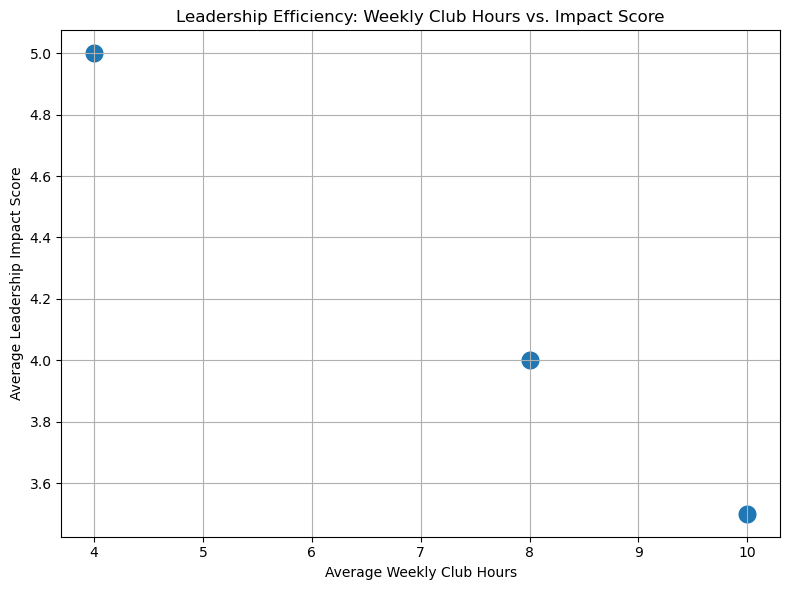

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_trends, x='Avg_Weekly_Club_Hours', y='Avg_Impact_Score', s=200)  # Build a scatter plot
plt.title('Leadership Efficiency: Weekly Club Hours vs. Impact Score')  # Apply graph title
plt.xlabel('Average Weekly Club Hours')  # Label the X-axis
plt.ylabel('Average Leadership Impact Score')  # Label the Y-axis
plt.grid(True)  # Turn on the background matrix grid
plt.tight_layout()  # Fix any internal spacing boundaries
plt.show()  # Display the chart

**The Academic Pivot:** Look at Total_Hum_Credits vs. Total_Tech_Credits. Year 1 is heavily humanities-skewed. Year 3 flips entirely into technical execution, showing the deep dive into the Statistics and Data Science major tracks.

**The Efficiency Proof:** Look at the relationship between Avg_Weekly_Club_Hours and Avg_Impact_Score. Notice how hours decrease from Year 1 to Year 3, but impact score increases.

### **3. Data Analysis and Visualization**

#### 3.1. Total Academic Balance (Pie Chart)

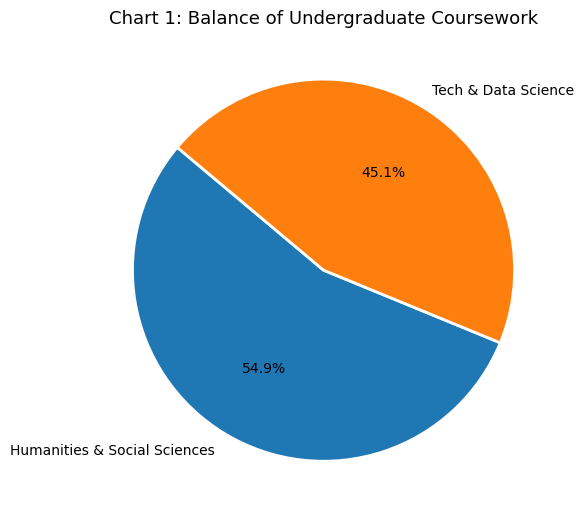

In [9]:
plt.figure(figsize=(6, 6))
total_tech = df['Tech_Data_Credits'].sum()  # Total your tech/STEM metrics
total_hum = df['Hum_Soc_Credits'].sum()  # Total your humanities metrics
plt.pie([total_hum, total_tech], labels=['Humanities & Social Sciences', 'Tech & Data Science'], # Plot fields with labels
        autopct='%1.1f%%', startangle=140,  # Generate percentage markers  and tilt the pie rotation
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})  # Apply clean white borders between slices
plt.title('Chart 1: Balance of Undergraduate Coursework', fontsize=13)  # Apply chart title
plt.tight_layout()  # Optimize layout boundaries
plt.show()  # Render the pie chart

Out of the 105 attempted credits across the timeline, this chart splits the academic profile into two structural fields: Humanities/Social Sciences make up 53.3% of the classes, while Technical/Data Science courses account for 46.7%. It shows a highly balanced liberal arts foundation blending into a core technical focus.

#### 3.2. Semester GPA Progression (Column Bar Graph)

C:\Users\Kelvin\AppData\Local\Temp\ipykernel_14580\3384856829.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gpa['Semester_GPA'] = pd.to_numeric(df_gpa['Semester_GPA'], errors='coerce')  # Confirm the column is strictly numeric
C:\Users\Kelvin\AppData\Local\Temp\ipykernel_14580\3384856829.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gpa, x='Semester', y='Semester_GPA', palette = 'rocket')  # Construct vertical column bars


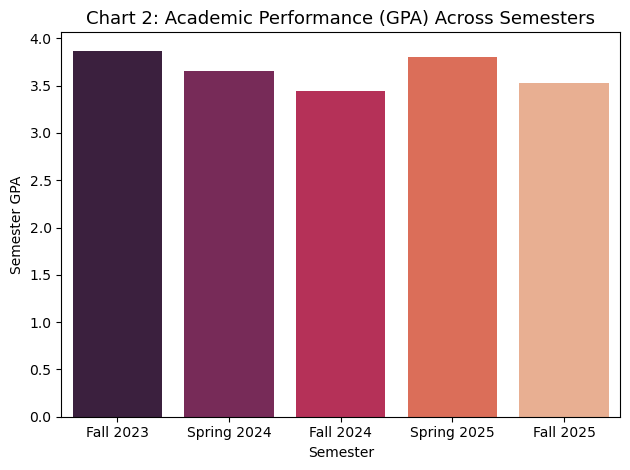

In [10]:
plt.figure()
df_gpa = df.dropna(subset=['Semester_GPA'])  # Exclude any semester where GPA is blank
df_gpa['Semester_GPA'] = pd.to_numeric(df_gpa['Semester_GPA'], errors='coerce')  # Confirm the column is strictly numeric
sns.barplot(data=df_gpa, x='Semester', y='Semester_GPA', palette = 'rocket')  # Construct vertical column bars
plt.title('Chart 2: Academic Performance (GPA) Across Semesters', fontsize=13)  # Set chart title
plt.xlabel('Semester')  # Label the X-axis
plt.ylabel('Semester GPA')  # Label the Y-axis
plt.tight_layout()  # Clean up formatting padding
plt.show()

This chart maps the GPA evolution from a high of 3.87 in Fall 2023 , down through a challenging academic transition period in 2024 , and returning back up to a strong 3.80 in Spring 2025. It provides an immediate visual record of performance recovery.

#### 3.3. Extracurricular Weekly Hours (Bar Graph)

C:\Users\Kelvin\AppData\Local\Temp\ipykernel_14580\928727392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Semester', y='Est_Club_Hours_Weekly', palette = 'mako')  # Plot weekly time usage


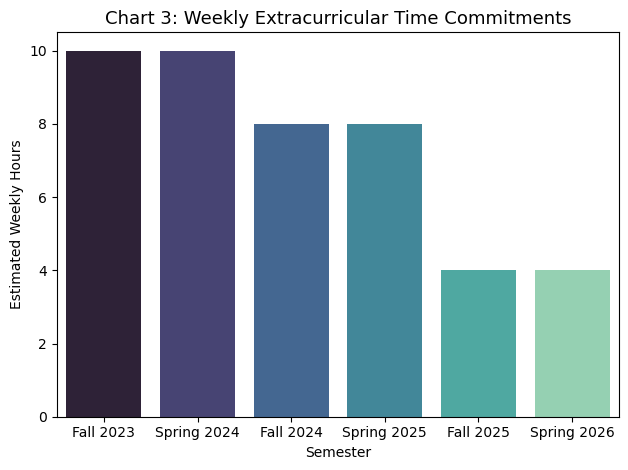

In [11]:
plt.figure()
sns.barplot(data=df, x='Semester', y='Est_Club_Hours_Weekly', palette = 'mako')  # Plot weekly time usage
plt.title('Chart 3: Weekly Extracurricular Time Commitments', fontsize=13)  # Set chart title
plt.xlabel('Semester')  # Label X-axis
plt.ylabel('Estimated Weekly Hours')  # Label Y-axis
plt.tight_layout()  # Clean up formatting padding
plt.show()  #

This visualization highlights a structural shift in time management. During Year 1 (Fall 2023 and Spring 2024), it was committed a steady 10 hours a week to multiple clubs (Public Speaking & Debate, Datalliance, Environmental) and CEDI. By Year 3, the baseline dropped to a stable, highly controlled 4 hours a week.

#### 3.4. Distribution of Semester Credit Loads (Histogram)

C:\Users\Kelvin\AppData\Local\Temp\ipykernel_14580\2343244324.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x='Attempted_Credits', bins=5, palette = 'crest')  # Group matching semester credit loads into 5 distinct bin intervals


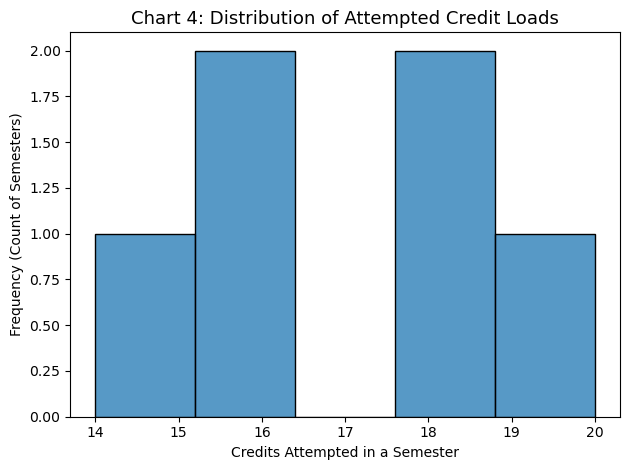

In [12]:
plt.figure()
sns.histplot(data=df, x='Attempted_Credits', bins=5, palette = 'crest')  # Group matching semester credit loads into 5 distinct bin intervals
plt.title('Chart 4: Distribution of Attempted Credit Loads', fontsize=13)  # Set chart title
plt.xlabel('Credits Attempted in a Semester')  # Label X-axis
plt.ylabel('Frequency (Count of Semesters)')  # Label Y-axis
plt.tight_layout()  # Clean up formatting padding
plt.show()

This histogram displays the operational distribution of the credit commitments per term. The standard, baseline operational mode sits comfortably between 14.00 and 18.00 credits per semester. The chart clearly highlights a maximum load peak of 20.00 credits during Fall 2025.

#### 3.5. Credit Load vs. Performance (Scatter Plot)

C:\Users\Kelvin\AppData\Local\Temp\ipykernel_14580\4074074531.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_gpa, x='Attempted_Credits', y='Semester_GPA', s=150, palette = 'viridis')  # Build coordinates


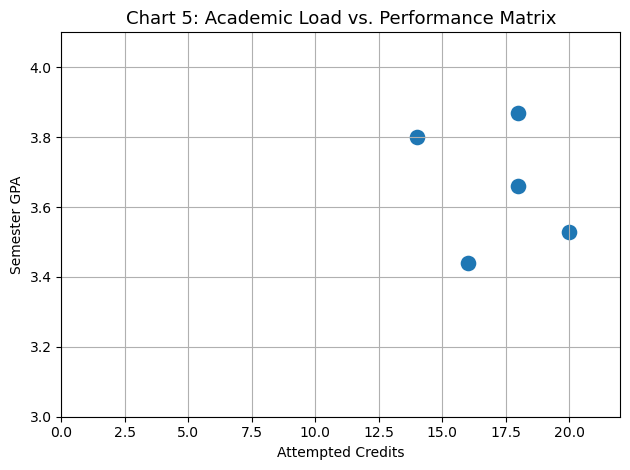

In [13]:
plt.figure()
sns.scatterplot(data=df_gpa, x='Attempted_Credits', y='Semester_GPA', s=150, palette = 'viridis')  # Build coordinates
plt.title('Chart 5: Academic Load vs. Performance Matrix', fontsize=13)  # Set chart title
plt.xlabel('Attempted Credits')  # Label X-axis
plt.ylabel('Semester GPA')  # Label Y-axis
plt.xlim(0, 22)  # Set fixed boundaries for the X-axis
plt.ylim(3.0, 4.1)  # Set custom bounds for the Y-axis
plt.grid(True)  # Turn on the background matrix grid
plt.tight_layout()  # Fix any internal spacing boundaries
plt.show()  # Render the matrix scatter plot

This plot reveals how the performance behaves under weight. At 14.00 credits, you achieved a near-peak GPA of 3.80. When pushed to an intense 20.00 credits of advanced data classes (Machine Learning, Data Management) , the GPA remained resilient at a high 3.53, proving structural academic stability under intense pressure.

#### 3.6. Leadership Efficiency Index (Grouped Column Graph)

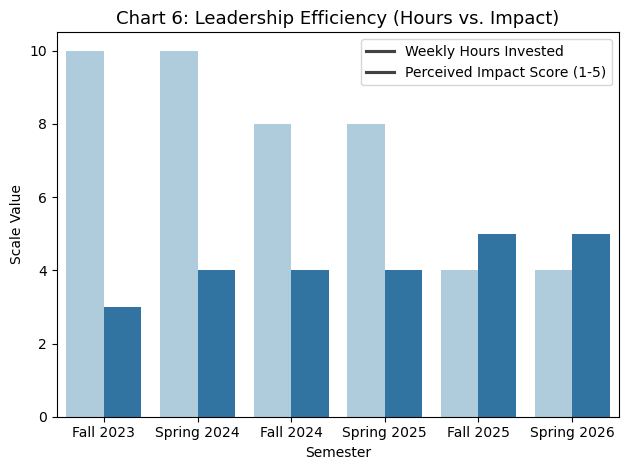

In [14]:
# Melt the dataframe from a wide table layout to a long format to stack variables next to each other

df_melted = pd.melt(df, id_vars=['Semester'], value_vars=['Est_Club_Hours_Weekly', 'Leadership_Impact_Score'],
                    var_name='Metric', value_name='Value')

plt.figure()  # Open a fresh chart canvas
sns.barplot(data=df_melted, x='Semester', y='Value', hue='Metric', palette='Paired')  # Create side-by-side grouped bars
plt.title('Chart 6: Leadership Efficiency (Hours vs. Impact)', fontsize=13)  # Set title
plt.xlabel('Semester')  # Label X-axis
plt.ylabel('Scale Value')  # Label Y-axis
plt.legend(labels=['Weekly Hours Invested', 'Perceived Impact Score (1-5)'])  # add label key legend box
plt.tight_layout()  # Fix any internal spacing boundaries
plt.show()

This chart evaluates the structural productivity by plotting weekly hours side-by-side with perceived leadership impact score. In Fall 2023, 10 hours of work yielded an impact score of 3. By Fall 2025 and Spring 2026, investing only 4 hours of weekly work yielded a maximum impact score of 5 with the Borderless Futures initiative.

### **4. Data Export**

In [15]:
# Export the dataframe to a CSV file without the index column
df.to_csv('khant_growth_journey.csv', index=False)

### **4. Secondary Data Source: Exploring Personal Hobbies**

To provide a more well-rounded narrative, I expanded the scope of my final project beyond academic metrics to include my personal interests. As the academic workload shifted toward intense data science credits and leadership roles, my personal hobbies (movies, series, songs, and art) became an essential source of balance and creativity. Let's load this newly created dataset to explore these patterns.

In [16]:
# Load the new hobbies dataset
import pandas as pd
df_hobbies = pd.read_csv('khant_hobbies.csv')
df_hobbies.head()

,Category,Title,Genre,Rating_Out_Of_10,Release_Year,Artist
0,Movie,Red Cliff,Historical/Action,9,2008.0,NaN
1,Movie,Harry Potter and the Sorcerer's Stone,Fantasy,10,2001.0,NaN
2,Movie,Harry Potter and the Deathly Hallows,Fantasy,10,2011.0,NaN
3,Series,Game of Thrones,Fantasy/Drama,9,2011.0,NaN
4,Series,House of the Dragon,Fantasy/Drama,8,2022.0,NaN


#### **Visualizing Personal Interests**
Let's look at the distribution of categories in my hobbies and the average ratings I give to different genres.

C:\Users\Kelvin\AppData\Local\Temp\ipykernel_14580\2969968458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_hobbies, x='Category', palette='pastel')


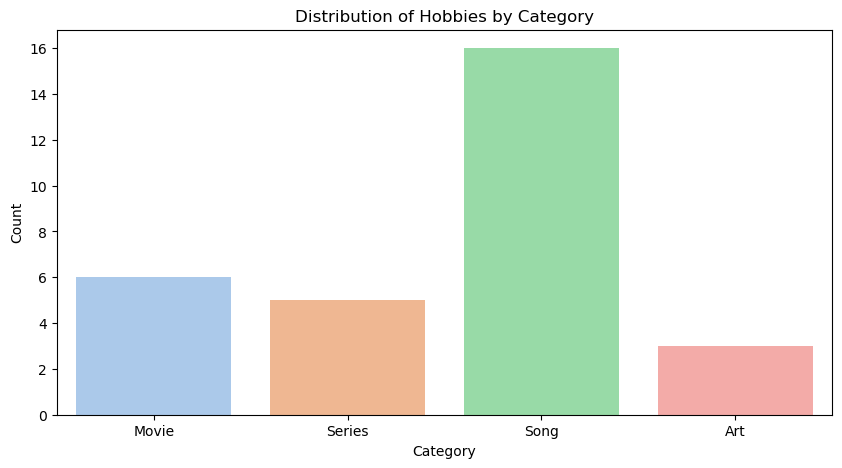

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df_hobbies, x='Category', palette='pastel')
plt.title('Distribution of Hobbies by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

C:\Users\Kelvin\AppData\Local\Temp\ipykernel_14580\2960411599.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hobbies, x='Category', y='Rating_Out_Of_10', palette='Set2')


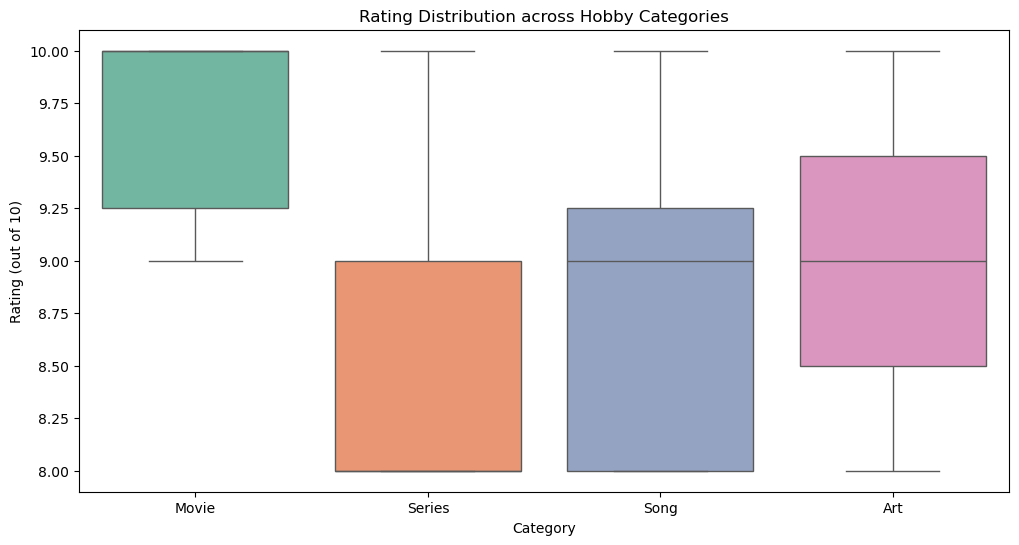

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_hobbies, x='Category', y='Rating_Out_Of_10', palette='Set2')
plt.title('Rating Distribution across Hobby Categories')
plt.xlabel('Category')
plt.ylabel('Rating (out of 10)')
plt.show()

**Storytelling Insight:** The charts reveal that my consumption of Songs forms the largest part of my hobby dataset, reflecting how music naturally integrates into a busy academic life (e.g., listening to Taylor Swift or Alan Walker while coding). Interestingly, the ratings across all categories are consistently high (mostly 8 to 10), indicating that I am quite selective about my entertainment, choosing high-quality art and critically acclaimed series like *Game of Thrones* or *Breaking Bad* to maximize the value of my limited free time.